# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [6]:
import sys
print(sys.executable)

/home/anshu/EmotionDetection-from-voice/venv/bin/python


In [7]:
import matplotlib.pyplot as plt
import librosa.display

print("ALL GOOD ✅")

ALL GOOD ✅


In [8]:
import glob
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

# Dataset Selection

In [9]:
import glob
import os

data_directory = "/media/anshu/New Volume/Dataset"

wav_files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

files = wav_files 

print("WAV:", len(wav_files))

WAV: 2452


In [10]:
import os
import platform

print("Using dataset path:", data_directory)

if not os.path.exists(data_directory):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{data_directory}

Please update the path in Dataset Selection section.
""")

Using dataset path: /media/anshu/New Volume/Dataset


In [11]:
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

## 1.1 Dataset Emotion Distribution

Total WAV files: 2452


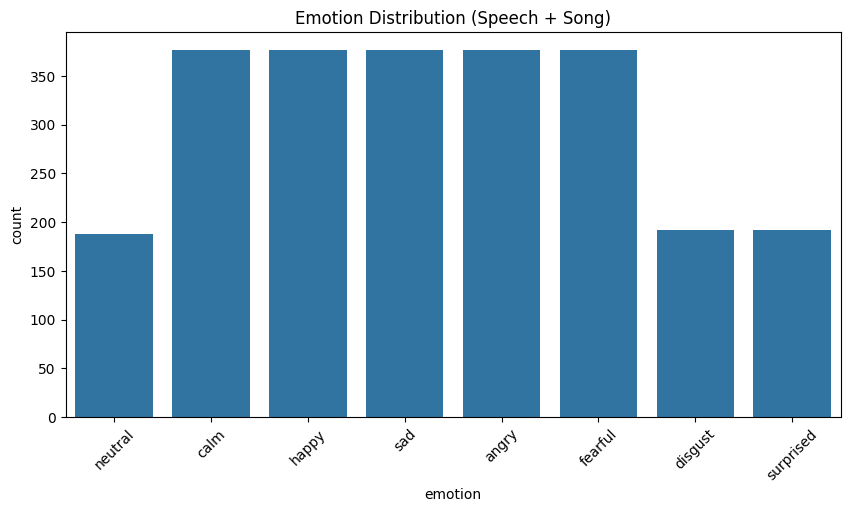

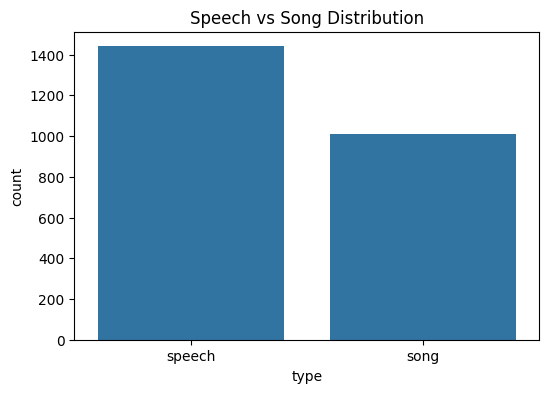

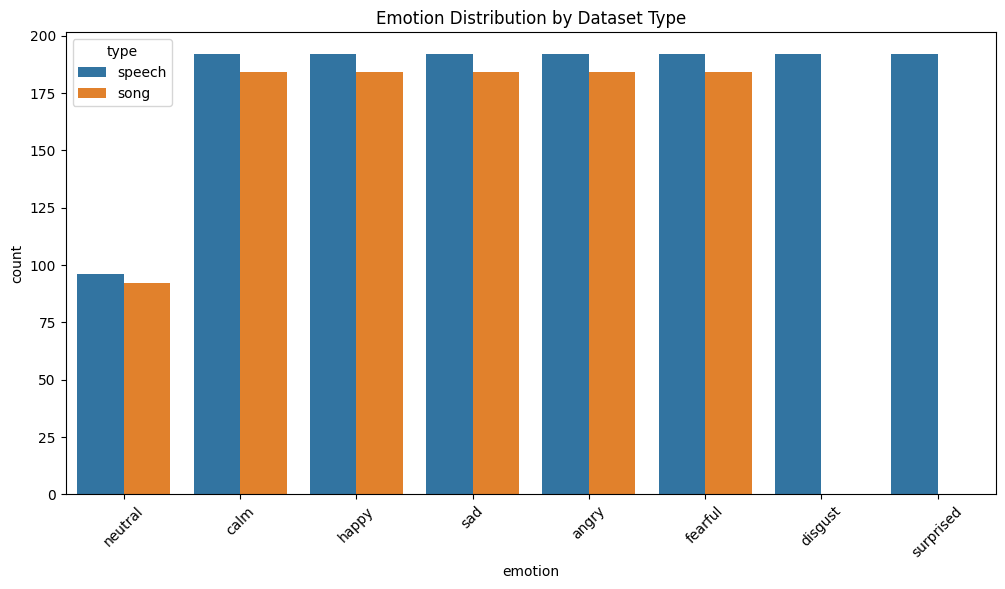

In [12]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- STEP 1: Define dataset paths ----------
base_path = "/media/anshu/New Volume/Dataset"

speech_path = os.path.join(base_path, "Audio_Speech_Actors_01-24")
song_path   = os.path.join(base_path, "Audio_Song_Actors_01-24")

# ---------- STEP 2: Load ALL wav files (Speech + Song) ----------
processed_files = []

for dataset_path in [speech_path, song_path]:
    for actor in os.listdir(dataset_path):
        actor_path = os.path.join(dataset_path, actor)

        if not os.path.isdir(actor_path):
            continue

        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                processed_files.append(os.path.join(actor_path, file))

print("Total WAV files:", len(processed_files))

# ---------- STEP 3: Extract emotions + dataset type ----------
emotion_list = []
dataset_type_list = []

for file in processed_files:
    file_name = os.path.basename(file)

    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]

    if emotion_code not in emotion_map_number:
        continue

    emotion = emotion_map_number[emotion_code]
    emotion_list.append(emotion)

    # 🔥 Track dataset type
    if "Speech" in file:
        dataset_type_list.append("speech")
    else:
        dataset_type_list.append("song")

# ---------- STEP 4: Create DataFrame ----------
df = pd.DataFrame({
    "emotion": emotion_list,
    "type": dataset_type_list
})

# ---------- STEP 5: Plot Emotion Distribution ----------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution (Speech + Song)")
plt.xticks(rotation=45)
plt.show()

# ---------- STEP 6: Plot Dataset Balance ----------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="type")
plt.title("Speech vs Song Distribution")
plt.show()

# ---------- STEP 7: Combined View ----------
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="emotion", hue="type")
plt.title("Emotion Distribution by Dataset Type")
plt.xticks(rotation=45)
plt.show()

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

def visualize_features(file_path):

    # ---------- LOAD WAV ONLY ----------
    try:
        data, sr = librosa.load(file_path, sr=22050)
    except:
        print("Error reading:", file_path)
        return

    # ---------- EXTRACT EMOTION ----------
    file_name = os.path.basename(file_path)

    parts = file_name.split("-")

    if len(parts) < 3:
        emotion = "unknown"
    else:
        emotion_code = parts[2]
        emotion = emotion_map_number.get(emotion_code, "unknown")

    # ---------- DETECT DATASET TYPE (NEW 🔥) ----------
    if "Speech" in file_path:
        dataset_type = "Speech"
    else:
        dataset_type = "Song"

    # ---------- FEATURE EXTRACTION ----------
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=data, sr=sr)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=data, sr=sr))
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr)
    zcr = librosa.feature.zero_crossing_rate(data)
    rms = librosa.feature.rms(y=data)

    # ---------- PLOT ----------
    plt.figure(figsize=(15, 20))
    plt.suptitle(f"{dataset_type} | Emotion: {emotion}", fontsize=16)

    # Waveform
    plt.subplot(8,1,1)
    librosa.display.waveshow(data, sr=sr)
    plt.title("Waveform")

    # MFCC
    plt.subplot(8,1,2)
    librosa.display.specshow(mfcc, x_axis='time')
    plt.colorbar()
    plt.title("MFCC (Timbre)")

    # Chroma
    plt.subplot(8,1,3)
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma')
    plt.colorbar()
    plt.title("Chroma (Pitch)")

    # Mel
    plt.subplot(8,1,4)
    librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Contrast
    plt.subplot(8,1,5)
    librosa.display.specshow(contrast, x_axis='time')
    plt.colorbar()
    plt.title("Spectral Contrast")

    # Tonnetz
    plt.subplot(8,1,6)
    librosa.display.specshow(tonnetz, x_axis='time')
    plt.colorbar()
    plt.title("Tonnetz")

    # ZCR
    plt.subplot(8,1,7)
    plt.plot(zcr[0])
    plt.title("ZCR")

    # RMS
    plt.subplot(8,1,8)
    plt.plot(rms[0])
    plt.title("RMS Energy")

    plt.tight_layout()
    plt.show()

File: /media/anshu/New Volume/Dataset/Audio_Speech_Actors_01-24/Actor_12/03-01-04-01-02-02-12.wav


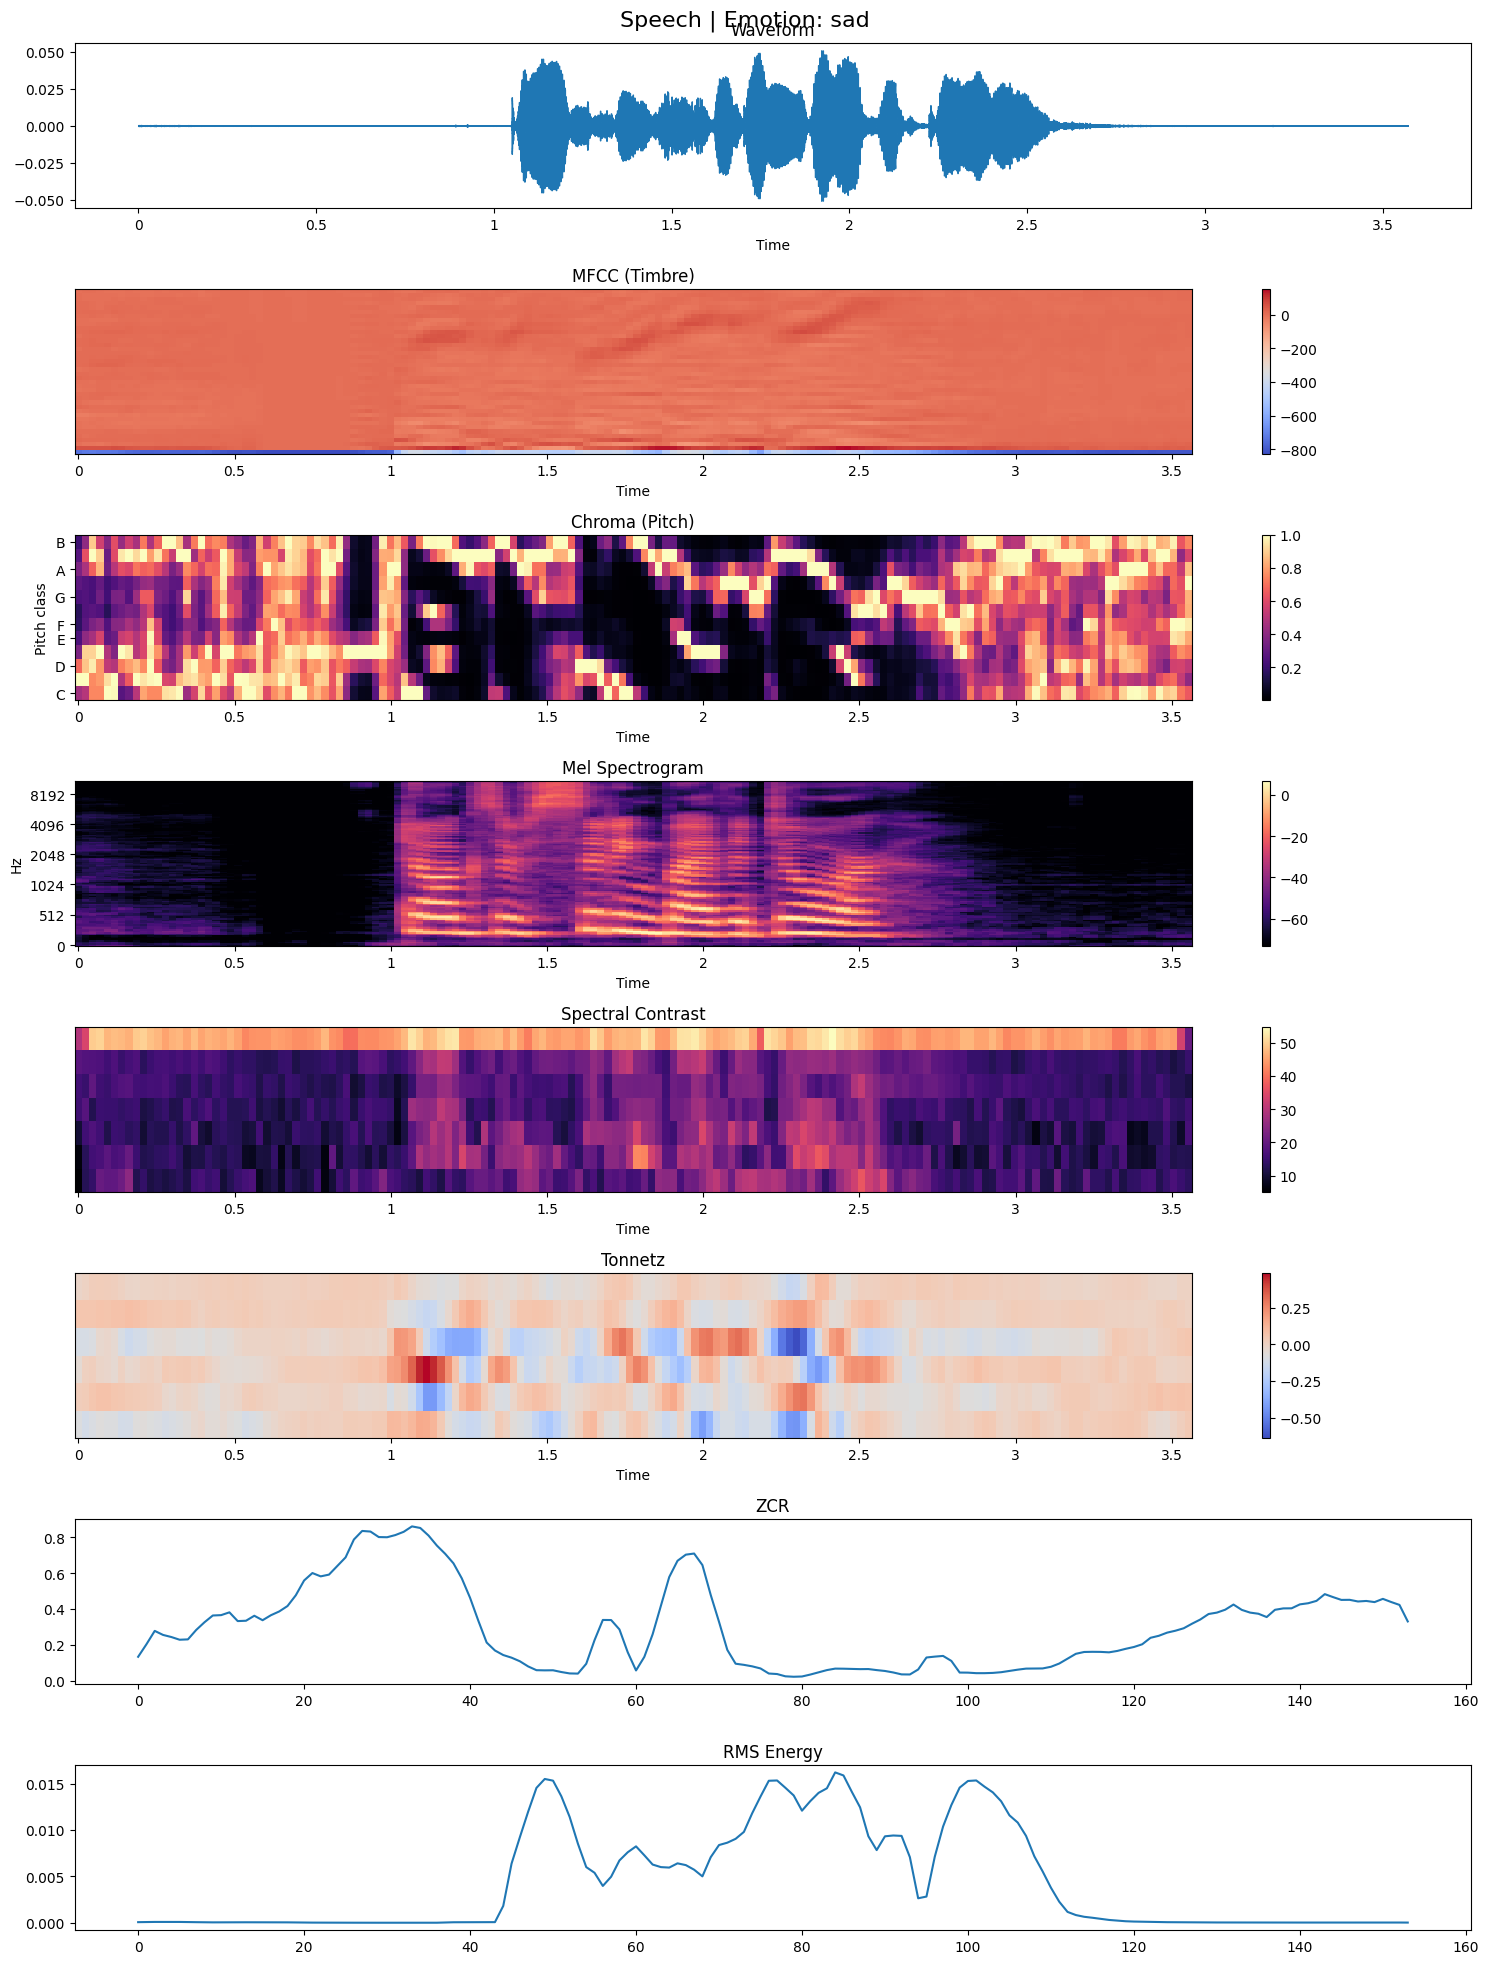

File: /media/anshu/New Volume/Dataset/Audio_Speech_Actors_01-24/Actor_12/03-01-06-02-02-01-12.wav


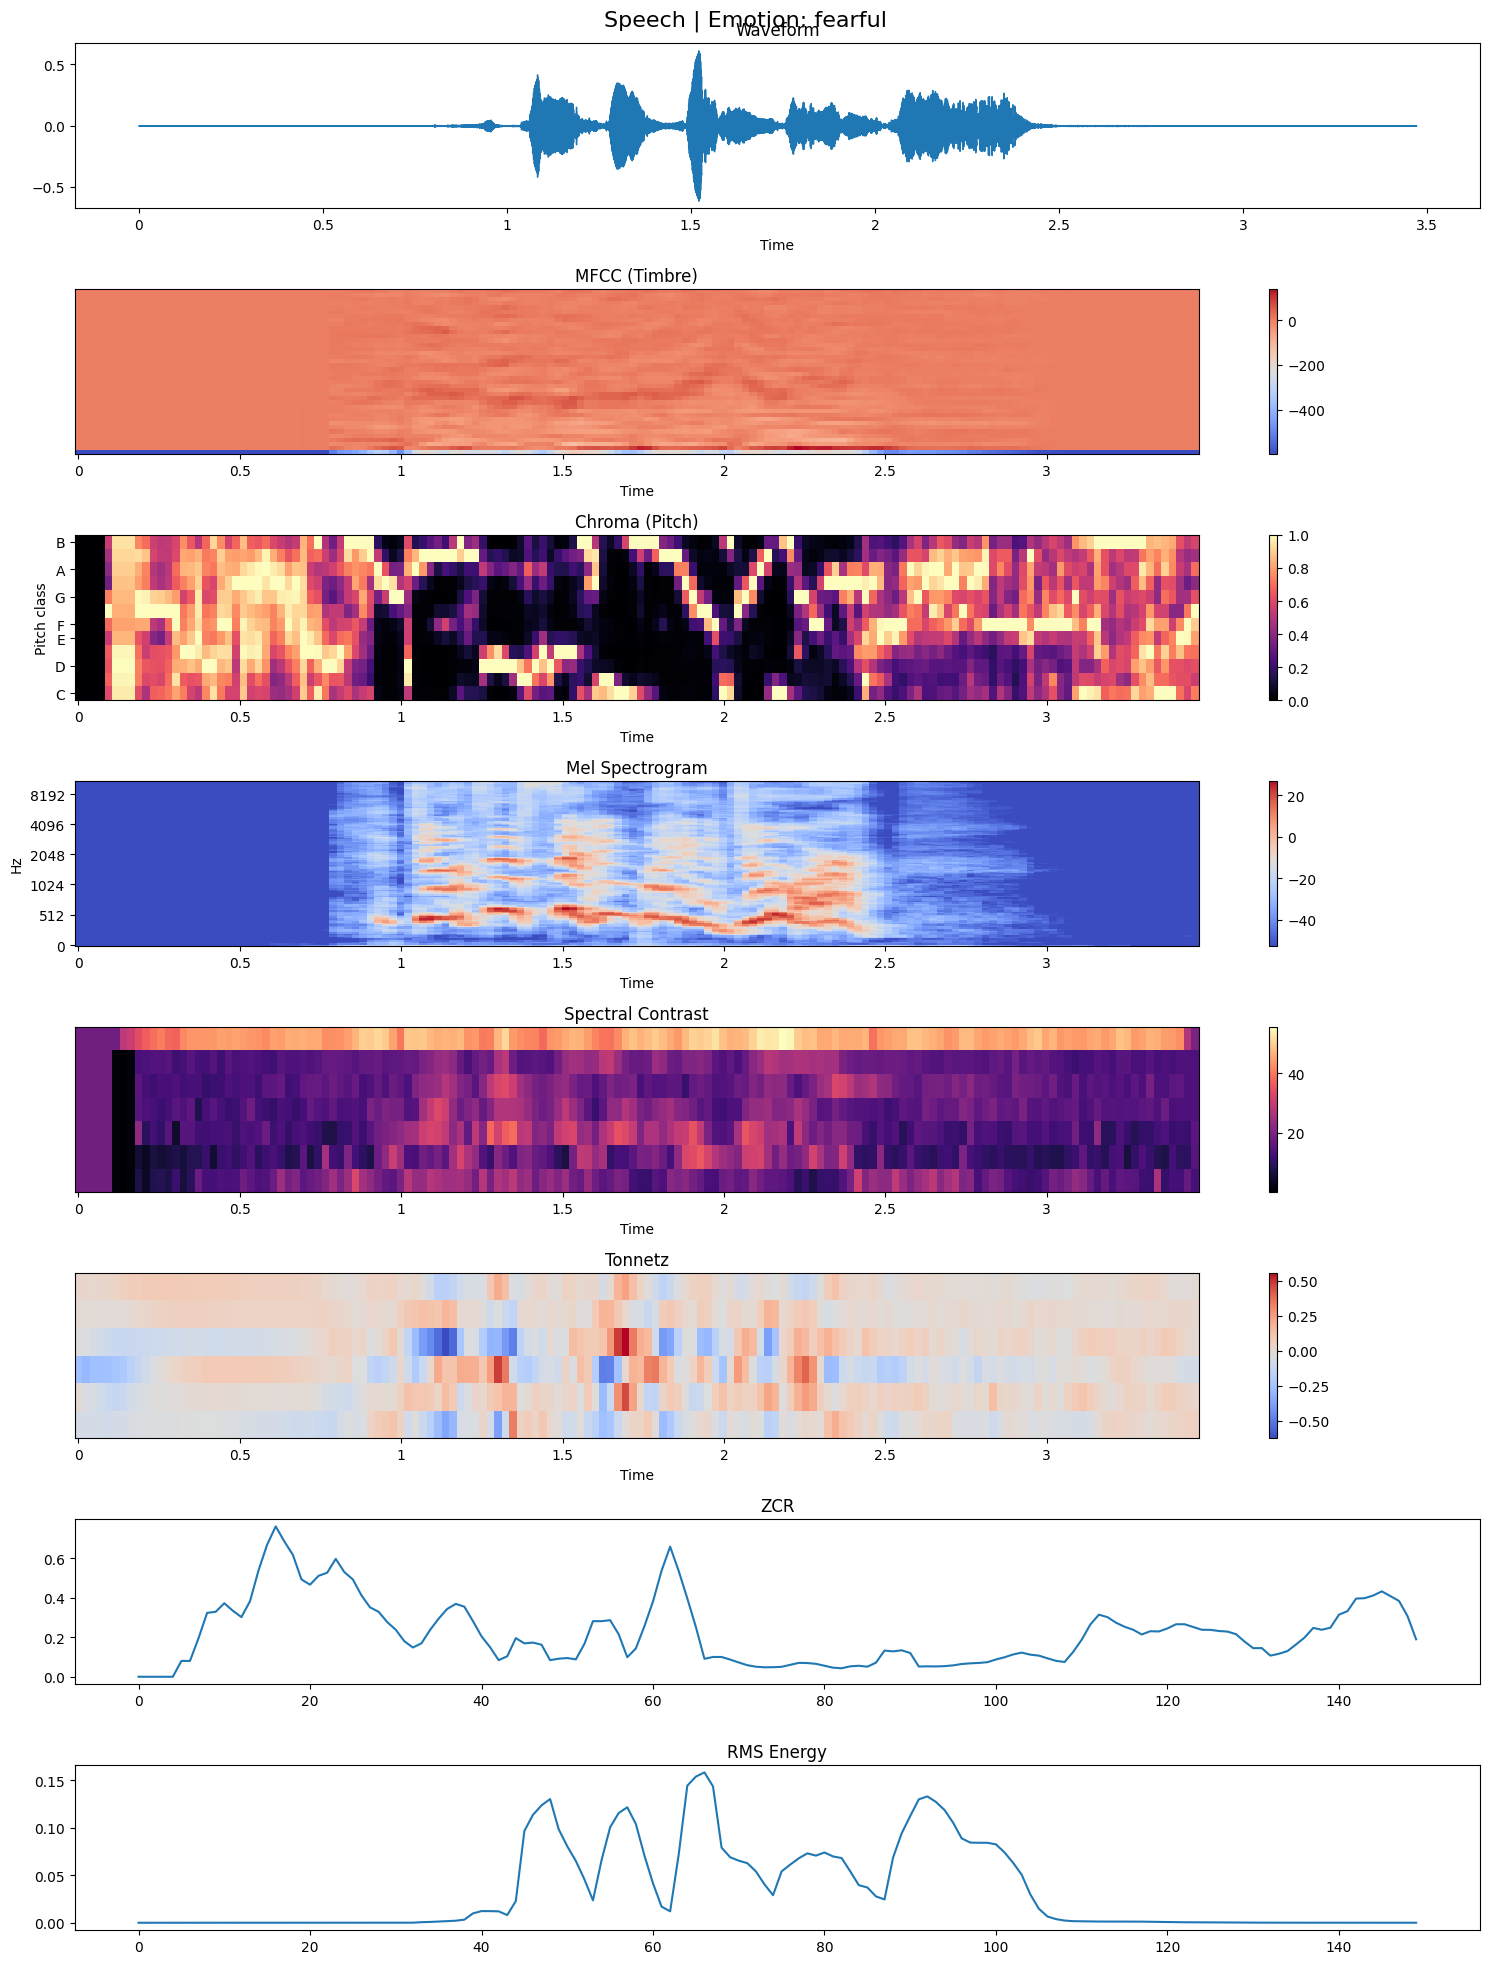

File: /media/anshu/New Volume/Dataset/Audio_Song_Actors_01-24/Actor_04/03-02-06-02-02-01-04.wav


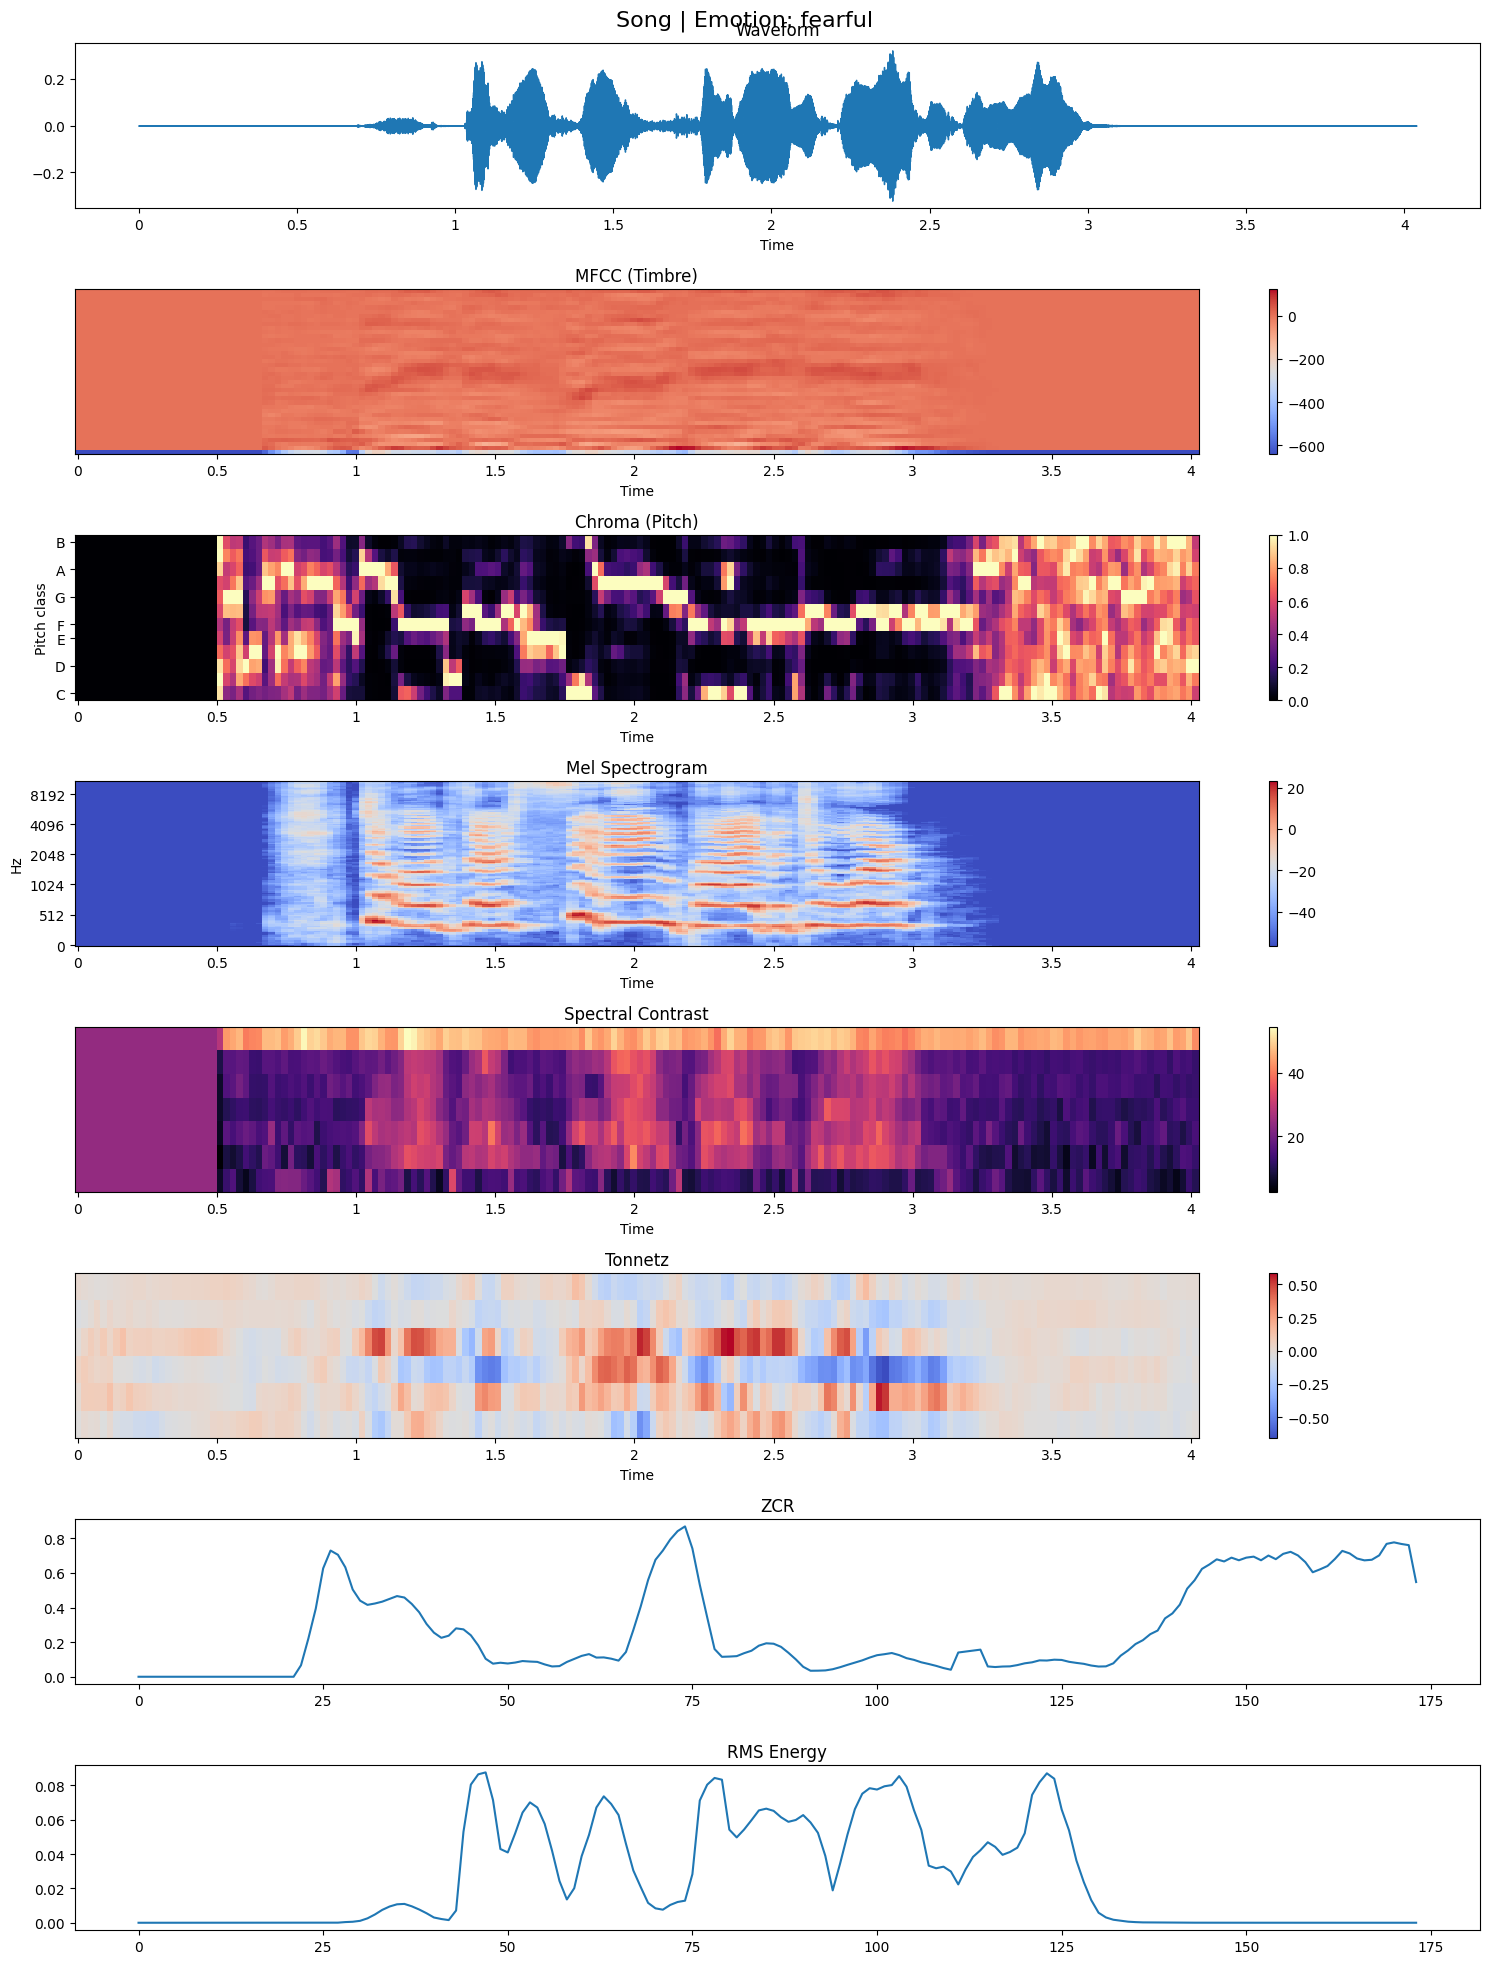

In [14]:
import random

for f in random.sample(processed_files, 3):
    print("File:", f)
    visualize_features(f)

# 1.2 Waveform Visualization

# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [15]:
emotion_map = {
'angry':0,
'calm':1,
'disgust':2,
'fearful':3,
'happy':4,
'neutral':5,
'sad':6,
'surprised':7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(8)

    if secondary:
        label[emotion_map[primary]] = w1
        label[emotion_map[secondary]] = w2
    else:
        label[emotion_map[primary]] = 1.0

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

In [16]:
def mix_multiple_audio(files, weights):

    signals = []
    target_sr = 22050   # 🔥 enforce consistent sample rate

    # ---------- LOAD AUDIO ----------
    for file in files:
        try:
            data, sr = librosa.load(file, sr=target_sr)
            signals.append(data)
        except:
            print("Error loading:", file)
            return None, None

    # ---------- MATCH LENGTH ----------
    min_len = min(len(s) for s in signals)
    signals = [s[:min_len] for s in signals]

    # ---------- WEIGHTED MIX ----------
    mixed = np.zeros(min_len)

    for s, w in zip(signals, weights):
        mixed += w * s

    # ---------- NORMALIZE ----------
    max_val = np.max(np.abs(mixed)) + 1e-6
    mixed = mixed / max_val

    return mixed, target_sr

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [17]:
np.random.seed(42)

In [18]:
def extract_feature(data, sr, dataset_type):

    # ---------- FEATURES ----------
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=data, sr=sr).T, axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    contrast = np.mean(librosa.feature.spectral_contrast(y=data, sr=sr).T, axis=0)
    tonnetz = np.mean(
        librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr).T,
        axis=0
    )
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)

    # ---------- COMBINE ----------
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, rms])

    # ---------- ADD DOMAIN FEATURE (VERY IMPORTANT) ----------
    return np.hstack([features, dataset_type])

In [19]:
emotion_files = {}

for file in processed_files:
    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]

    if emotion_code not in emotion_map_number:
        continue

    emotion = emotion_map_number[emotion_code]

    if emotion not in emotion_files:
        emotion_files[emotion] = []

    emotion_files[emotion].append(file)

# Debug check
for k, v in emotion_files.items():
    print(f"{k}: {len(v)} files")

neutral: 188 files
calm: 376 files
happy: 376 files
sad: 376 files
angry: 376 files
fearful: 376 files
disgust: 192 files
surprised: 192 files


In [20]:
# ===== IMPORTS =====
from joblib import Parallel, delayed
import multiprocessing
import numpy as np
import os
import librosa

# ===== CPU CORES =====
num_cores = multiprocessing.cpu_count() - 1  # keep 1 core free

# ===== PROCESS FUNCTION =====
def process_file(file, emotion_files, emotion_map, emotion_map_number):

    local_X = []
    local_y = []
    local_labels = []
    local_files = []

    try:
        data, sr = librosa.load(file, sr=22050)
    except:
        return local_X, local_y, local_labels, local_files

    dataset_type = 0 if "Speech" in file else 1

    # -------- ORIGINAL SAMPLE --------
    feature = extract_feature(data, sr, dataset_type)

    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        return local_X, local_y, local_labels, local_files

    emotion_code = parts[2]

    if emotion_code not in emotion_map_number:
        return local_X, local_y, local_labels, local_files

    primary_emotion = emotion_map_number[emotion_code]

    local_X.append(feature)
    local_y.append(create_soft_label(primary_emotion))
    local_labels.append(primary_emotion)
    local_files.append(file)

    # -------- MIXED SAMPLE --------
    if np.random.rand() < 0.05:

        n_mix = 2
        emotion_list_local = list(emotion_map.keys())

        selected_emotions = np.random.choice(emotion_list_local, n_mix, replace=False)

        domain = np.random.choice(["Speech", "Song"])

        selected_files = []

        for emo in selected_emotions:
            candidates = [
                f for f in emotion_files[emo]
                if domain in f
            ]

            if len(candidates) == 0:
                return local_X, local_y, local_labels, local_files

            selected_files.append(np.random.choice(candidates))

        weights = np.random.dirichlet(np.ones(n_mix))

        mixed_audio, sr = mix_multiple_audio(selected_files, weights)

        if mixed_audio is not None:
            dataset_type = 0 if "Speech" in selected_files[0] else 1

            feature = extract_feature(mixed_audio, sr, dataset_type)

            local_X.append(feature)

            label = np.zeros(len(emotion_map))
            for emo, w in zip(selected_emotions, weights):
                label[emotion_map[emo]] = w

            local_y.append(label)
            local_files.append(selected_files[0])  # track source

    return local_X, local_y, local_labels, local_files


# ===== PARALLEL EXECUTION =====
results = Parallel(n_jobs=num_cores, backend="loky")(
    delayed(process_file)(
        file,
        emotion_files,
        emotion_map,
        emotion_map_number
    )
    for file in processed_files
)

# ===== MERGE RESULTS =====
X, y, label_check, file_list = [], [], [], []

for res_X, res_y, res_labels, res_files in results:
    X.extend(res_X)
    y.extend(res_y)
    label_check.extend(res_labels)
    file_list.extend(res_files)

# ===== CONVERT TO NUMPY =====
X = np.array(X)
y = np.array(y)
file_list = np.array(file_list)

# ===== DEBUG =====
print("Dataset shape:", X.shape)
print("Labels shape :", y.shape)
print("Files count  :", len(file_list))

# ===== SAFETY CHECK =====
assert len(X) == len(y) == len(file_list), "Mismatch in dataset!"

/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1012
  warnings.warn(


Dataset shape: (2539, 195)
Labels shape : (2539, 8)
Files count  : 2539


# Normalize Features

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_flat = X.reshape(X.shape[0], -1)
X_flat = scaler.fit_transform(X_flat)
X = X_flat.reshape(X.shape)

# Saving the Features

In [22]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("emotion_map.pkl", "wb") as f:
    pickle.dump(emotion_map, f)

# Data Split

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
import os

def get_actor_id(file_path):
    return os.path.basename(os.path.dirname(file_path))


# ---------- SAFETY ----------
assert len(X) == len(y) == len(file_list), "Data mismatch!"

# ---------- ACTORS ----------
actors = np.array([get_actor_id(f) for f in file_list])
unique_actors = np.unique(actors)

train_actors, test_actors = train_test_split(
    unique_actors, test_size=0.2, random_state=42
)

# ---------- VECTORIZED SPLIT ----------
train_mask = np.isin(actors, train_actors)
test_mask  = np.isin(actors, test_actors)

X_train = X[train_mask]
y_train = y[train_mask]

X_test  = X[test_mask]
y_test  = y[test_mask]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (1998, 195)
Test : (541, 195)


In [24]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (1998, 195)
Test shape : (541, 195)


# Reshaping the Data

In [25]:
# X_train = np.expand_dims(X_train, axis=2)
# X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,                 # 🔥 slightly higher (complex dataset)
    restore_best_weights=True,
    min_delta=1e-4,              # 🔥 ignore tiny fluctuations
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,                  # 🔥 smoother LR drop
    patience=4,                  # 🔥 faster reaction
    min_lr=1e-6,                 # 🔥 prevent LR collapse
    verbose=1
)

I0000 00:00:1774622218.312750    8934 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774622218.316753    8934 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774622218.737422    8934 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774622220.187713    8934 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Model checkpoint

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",          # 🔥 explicit (lower val_loss is better)
    verbose=1            # 🔥 shows when model is saved
)

In [28]:
from sklearn.utils.class_weight import compute_class_weight

labels = np.argmax(y_train, axis=1)

classes = np.unique(labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

# ✅ Correct mapping
class_weights = dict(zip(classes, weights))

In [29]:
import tensorflow as tf

# ---------- CHECK GPU ----------
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU detected:", gpus)

    try:
        # Enable memory growth (VERY IMPORTANT)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        # Optional: set visible GPU
        tf.config.set_visible_devices(gpus[0], 'GPU')

    except RuntimeError as e:
        print("GPU setup error:", e)

else:
    print("❌ No GPU detected, using CPU")

❌ No GPU detected, using CPU


E0000 00:00:1774622222.691624    8934 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774622222.692026   10050 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774622222.708638    8934 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = np.argmax(y_train, axis=1)

classes = np.unique(labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weights = dict(zip(classes, weights))

# Convert to sample weights
sample_weights = np.array([class_weights[l] for l in labels])

X_train shape: (1998, 195, 1)
y_train shape: (1998, 8)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 193, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 193, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 94, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,504 (134.78 KB)

 Trainable params: 34,120 (133.28 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/600
59/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2240 - loss: 1.9716
Epoch 1: val_loss improved from None to 2.07874, saving model to best_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2613 - loss: 1.8928 - val_accuracy: 0.2052 - val_loss: 2.0787 - learning_rate: 0.0010
Epoch 2/600
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3121 - loss: 1.7683
Epoch 2: val_loss did not improve from 2.07874
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3168 - loss: 1.7425 - val_accuracy: 0.2237 - val_loss: 2.1160 - learning_rate: 0.0010
Epoch 3/600
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3334 - loss: 1.7148
Epoch 3: val_loss did not improve from 2.07874
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3368 - loss: 1.7190 - val_accuracy: 0.2717 - val_loss: 2.1341 - learning_rate: 0.0010
Epoch 4/600
58/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3359 - loss: 1.7046
Epoch 4: val_loss did not improve from 2.07874
63/63 ━━━━━━━━━━━

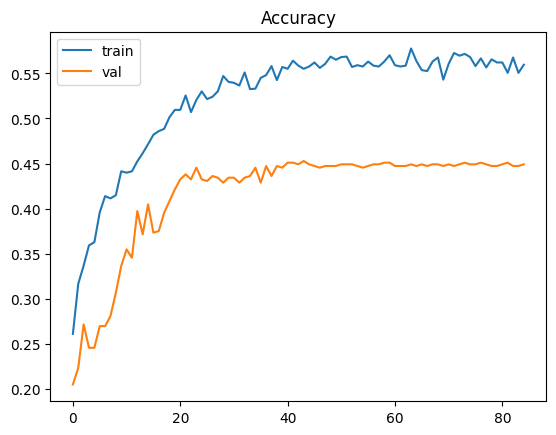

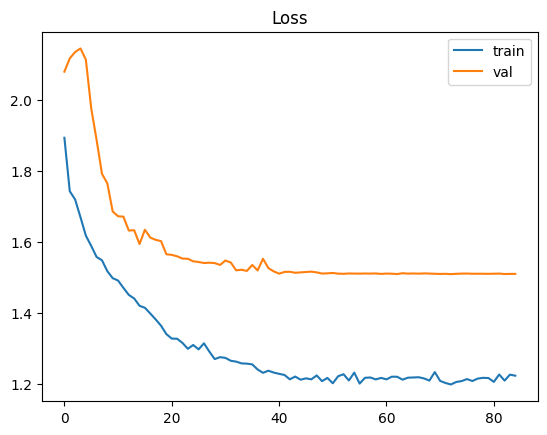

In [31]:
# ===== IMPORTS =====
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# ===== CONVERT TO HARD LABELS =====
y_train_hard = np.argmax(y_train, axis=1)
y_test_hard  = np.argmax(y_test, axis=1)

y_train_hard = to_categorical(y_train_hard, num_classes=8)
y_test_hard  = to_categorical(y_test_hard, num_classes=8)

# ===== SAFE RESHAPE =====
if len(X_train.shape) == 2:
    X_train = np.expand_dims(X_train, axis=-1)
    X_test  = np.expand_dims(X_test, axis=-1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_hard.shape)

# ===== SIMPLER MODEL =====
model = Sequential([
    Input(shape=X_train.shape[1:]),

    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',   # 🔥 simpler & stable
    metrics=['accuracy']
)

model.summary()

# ===== TRAIN =====
history = model.fit(
    X_train,
    y_train_hard,
    epochs=600,
    batch_size=32,
    validation_data=(X_test, y_test_hard),
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# ===== OPTIONAL: PLOT =====
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()

# Model Save

In [32]:
model.save("final_model_cnn.keras")

# Evaluation Matrics

In [33]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# ✅ FIX label names
inv_map = {v: k for k, v in emotion_map.items()}
target_names = [inv_map[i] for i in range(len(inv_map))]

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=target_names))

# 🔥 Top-2 Accuracy
top2 = np.mean([
    y_true[i] in np.argsort(y_pred[i])[-2:]
    for i in range(len(y_true))
])
print("\nTop-2 Accuracy:", top2)

# 🔥 Confidence Analysis
confidences = np.max(y_pred, axis=1)
print("Average confidence:", np.mean(confidences))
print("Low confidence samples (<0.5):", np.sum(confidences < 0.5))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Accuracy: 0.4491682070240296

Classification Report:

              precision    recall  f1-score   support

       angry       0.41      0.74      0.53        82
        calm       0.47      0.83      0.60        82
     disgust       0.24      0.09      0.13        43
     fearful       0.45      0.15      0.23        85
       happy       0.52      0.53      0.53        81
     neutral       0.69      0.21      0.33        42
         sad       0.42      0.39      0.40        83
   surprised       0.43      0.30      0.36        43

    accuracy                           0.45       541
   macro avg       0.45      0.41      0.39       541
weighted avg       0.45      0.45      0.41       541


Top-2 Accuracy: 0.6451016635859519
Average confidence: 0.44015226
Low confidence samples (<0.5): 373


# confusion matrix visual

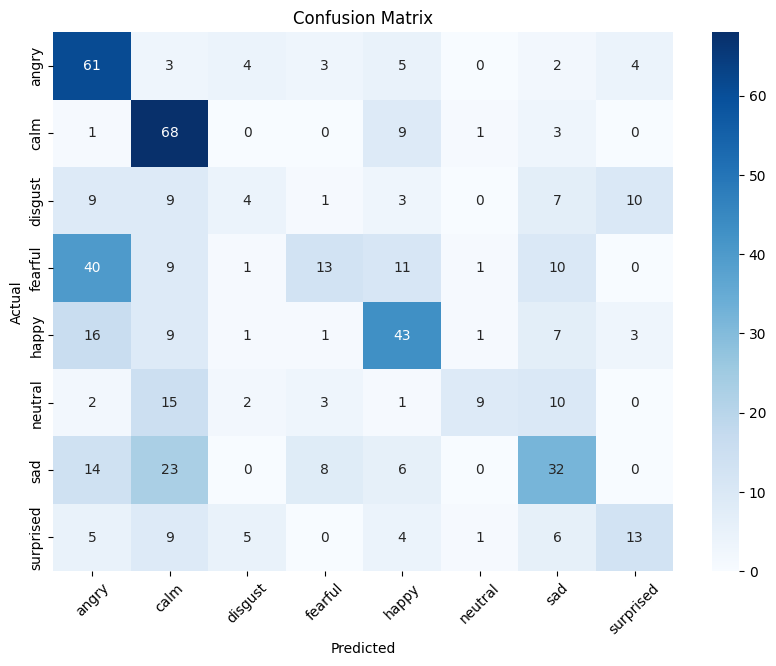

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.74390244 0.82926829 0.09302326 0.15294118 0.5308642  0.21428571
 0.38554217 0.30232558]
FPR: [0.18954248 0.16775599 0.02610442 0.03508772 0.08478261 0.00801603
 0.09825328 0.03413655]
TNR (Specificity): [0.81045752 0.83224401 0.97389558 0.96491228 0.91521739 0.99198397
 0.90174672 0.96586345]


In [36]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.40651910323481066
Mean FPR: 0.08045988424601898
Mean TNR: 0.9195401157539811


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.4531477591601414
Recall: 0.4491682070240296
F1 Score: 0.41171797242350366


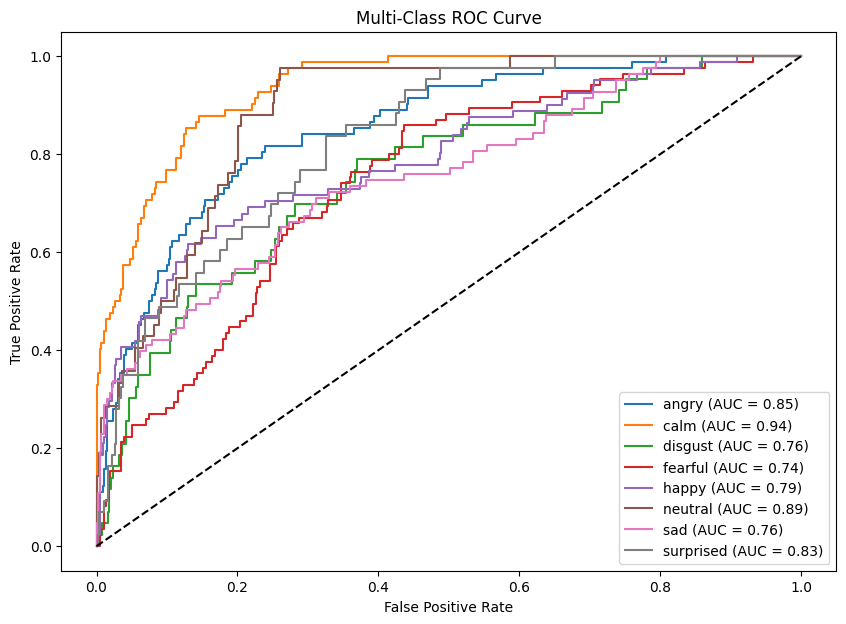

Average AUC: 0.8193638808469651


In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

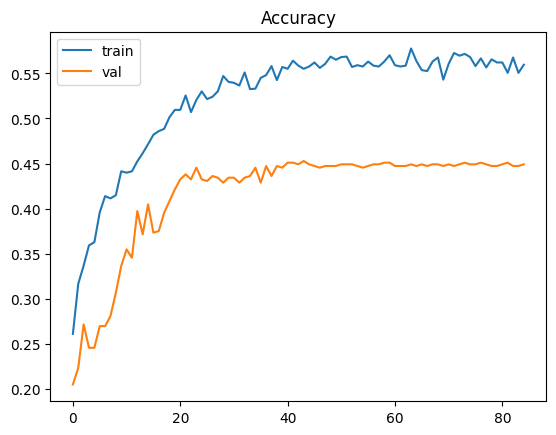

In [39]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

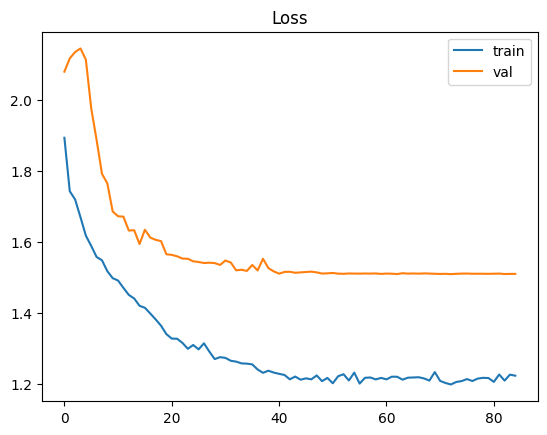

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [41]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn.keras")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4492 - loss: 1.5122  
Loaded model accuracy: 0.44916820526123047


### Save new audio:

In [42]:
emotions_sample = np.random.choice(list(emotion_map.keys()), 3, replace=False)
files = [np.random.choice(emotion_files[e]) for e in emotions_sample]
weights = np.random.dirichlet(np.ones(len(files)))

mixed, sr = mix_multiple_audio(files, weights)

sf.write("mixed_audio.wav", mixed, sr)

# Real-Time Emotion Detection

Record audio:

In [43]:
import sounddevice as sd

def record_audio(duration=3, sr=22050):

    print("Speak now")

    audio = sd.rec(int(duration*sr),
                   samplerate=sr,
                   channels=1)

    sd.wait()

    return audio.flatten()

# Predict emotion:

In [44]:
import pickle
from tensorflow.keras.models import load_model

loaded_model = loaded_model = load_model("final_model_cnn.keras")

# with open("scaler.pkl", "rb") as f:
#     scaler = pickle.load(f)

with open("emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

feature = (feature - np.mean(feature)) / (np.std(feature) + 1e-6)

feature = scaler.transform(feature.reshape(1, -1))
feature = feature.reshape(1, X.shape[1], X.shape[2], 1)


prediction = loaded_model.predict(feature)

inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)

Speak now


TypeError: extract_feature() missing 1 required positional argument: 'dataset_type'